In [186]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

In [187]:
df=pd.read_csv("/kaggle/input/mlcourse/video_games_sales.csv")

In [188]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [189]:
df.shape

(16719, 16)

In [190]:
mode=df["Year_of_Release"].mode()[0]
df["Year_of_Release"]=df["Year_of_Release"].fillna(mode)

mode=df["Genre"].mode()[0]
df["Genre"]=df["Genre"].fillna(mode)


mode=df["Publisher"].mode()[0]
df["Publisher"]=df["Publisher"].fillna(mode)

mean=df["Critic_Score"].mean()
df["Critic_Score"]=df["Critic_Score"].fillna(mean)

mode=df["Critic_Count"].mode()[0]
df["Critic_Count"]=df["Critic_Count"].fillna(mode)

mode=df["User_Score"].mode()[0]
df["User_Score"]=df["User_Score"].fillna(mode)



mean=df["User_Count"].mean()
df["User_Count"]=df["User_Count"].fillna(mean)


mode=df["Developer"].mode()[0]
df["Developer"]=df["Developer"].fillna(mode)


mode=df["Rating"].mode()[0]
df["Rating"]=df["Rating"].fillna(mode)

In [191]:
df.isnull().sum()

Name               2
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16719 non-null  float64
 3   Genre            16719 non-null  object 
 4   Publisher        16719 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     16719 non-null  float64
 11  Critic_Count     16719 non-null  float64
 12  User_Score       16719 non-null  object 
 13  User_Count       16719 non-null  float64
 14  Developer        16719 non-null  object 
 15  Rating           16719 non-null  object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [193]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000
mean,2006.511693,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,14.882828,162.229908
std,5.834610,0.813514,0.503283,0.308818,0.186710,1.547935,9.723417,17.327568,378.165132
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,68.967679,4.000000,30.000000
50%,2008.000000,0.080000,0.020000,0.000000,0.010000,0.170000,68.967679,4.000000,162.229908
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,70.000000,21.000000,162.229908
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [194]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.000000,51.0,8,322.000000,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,68.967679,4.0,tbd,162.229908,Ubisoft,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.000000,73.0,8.3,709.000000,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.000000,73.0,8,192.000000,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,68.967679,4.0,tbd,162.229908,Ubisoft,E


In [195]:
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

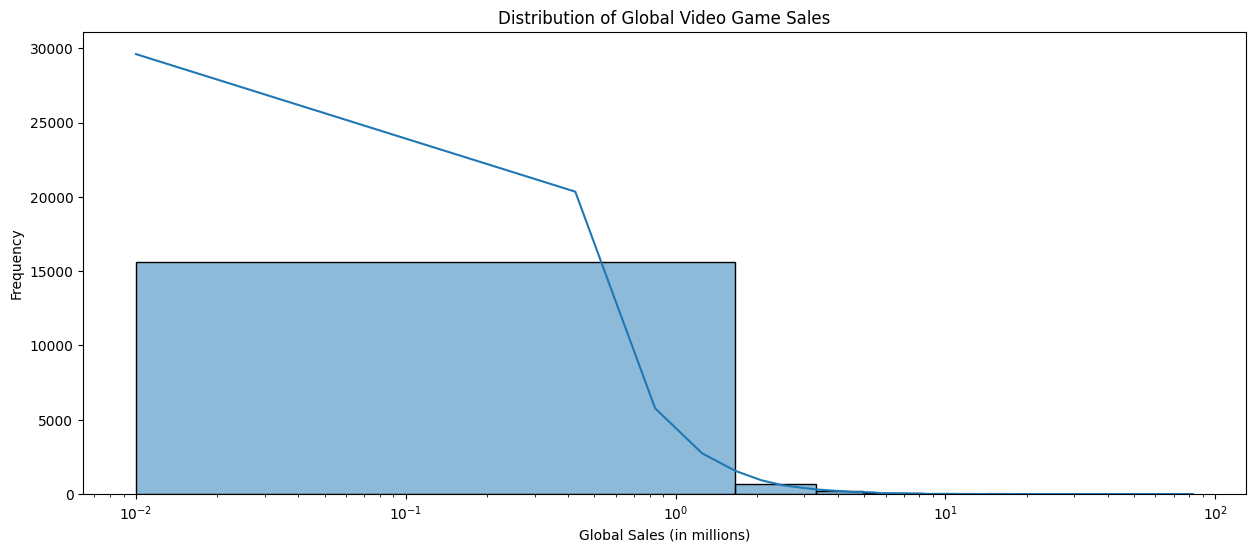

In [196]:
plt.figure(figsize=(15, 6))
sns.histplot(df['Global_Sales'], bins=50, kde=True)
plt.title('Distribution of Global Video Game Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.xscale('log')  
plt.show()

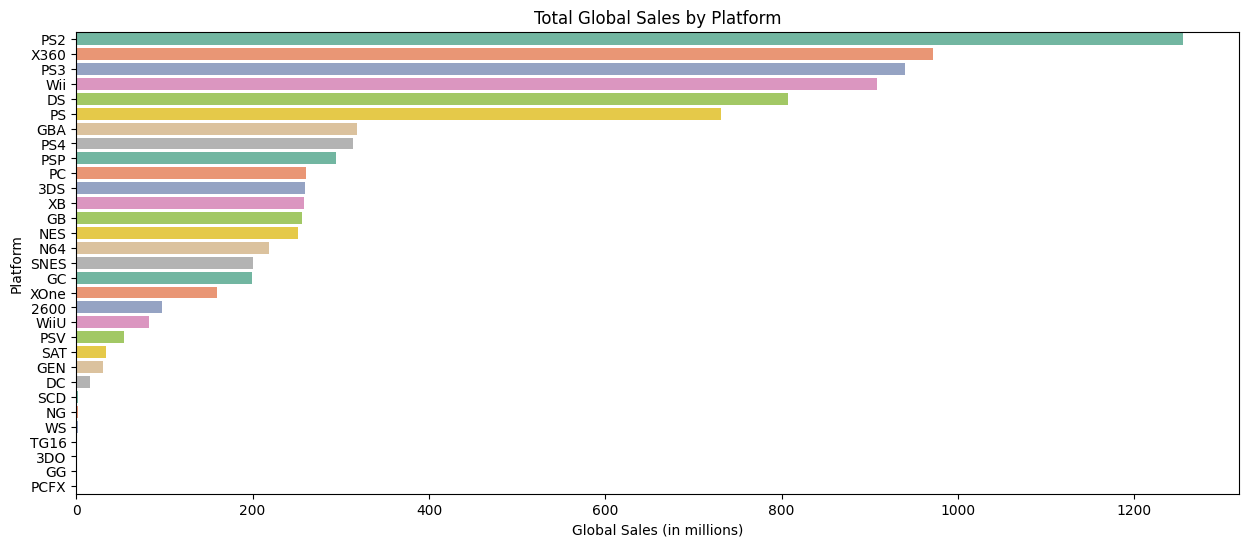

In [197]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 6))
sns.barplot(x=platform_sales.values, y=platform_sales.index,palette="Set2")
plt.title('Total Global Sales by Platform')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Platform')
plt.show()

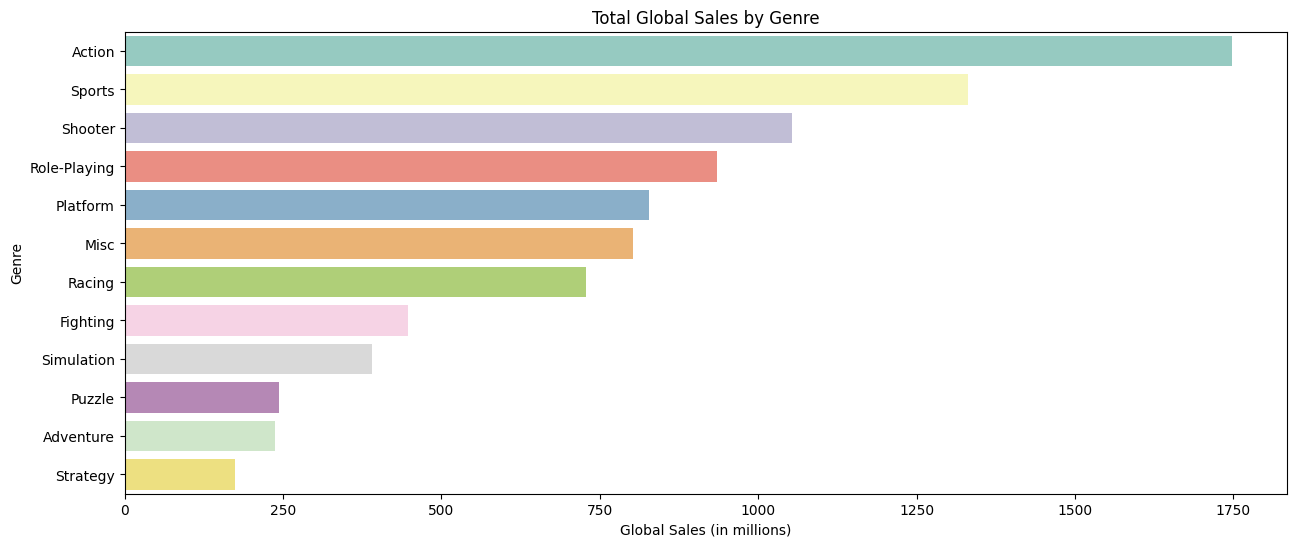

In [198]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index,palette="Set3")
plt.title('Total Global Sales by Genre')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Genre')
plt.show()

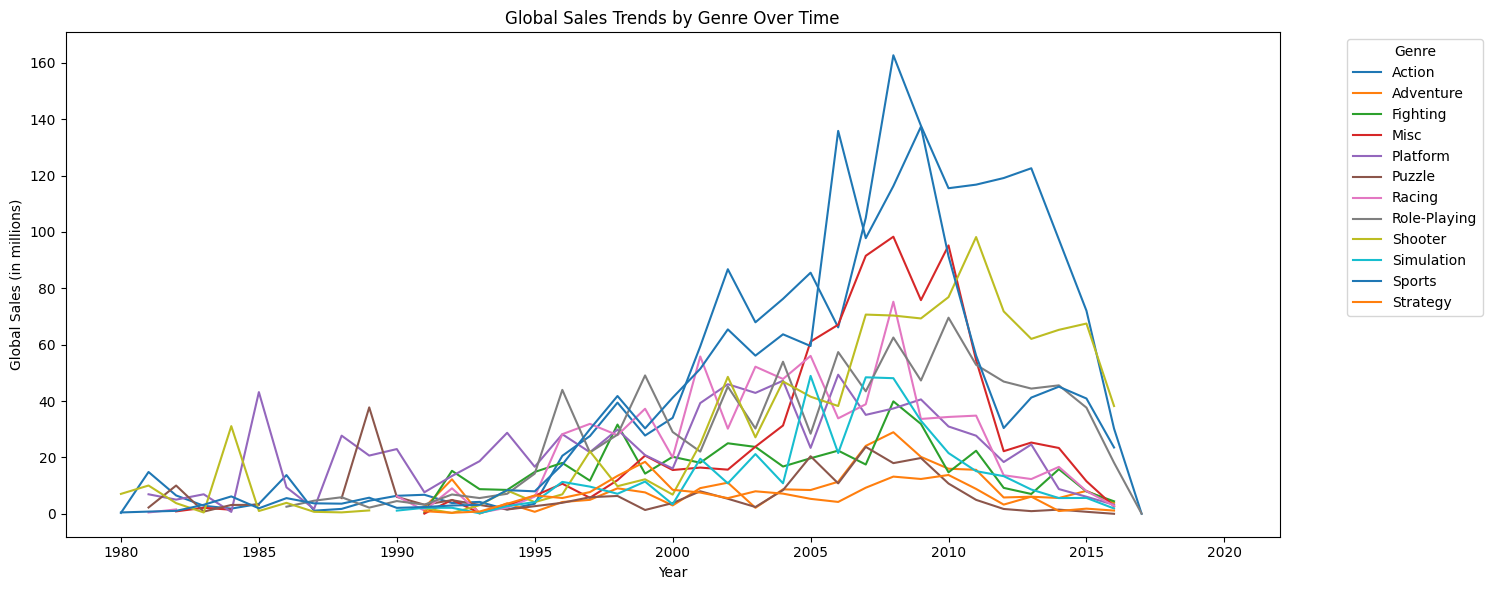

In [199]:
genre_year_sales = df.groupby(['Year_of_Release', 'Genre'])['Global_Sales'].sum().unstack()
genre_year_sales.plot(kind='line', stacked=False,figsize=(15,6))
plt.title('Global Sales Trends by Genre Over Time')
plt.xlabel('Year')
plt.ylabel('Global Sales (in millions)')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

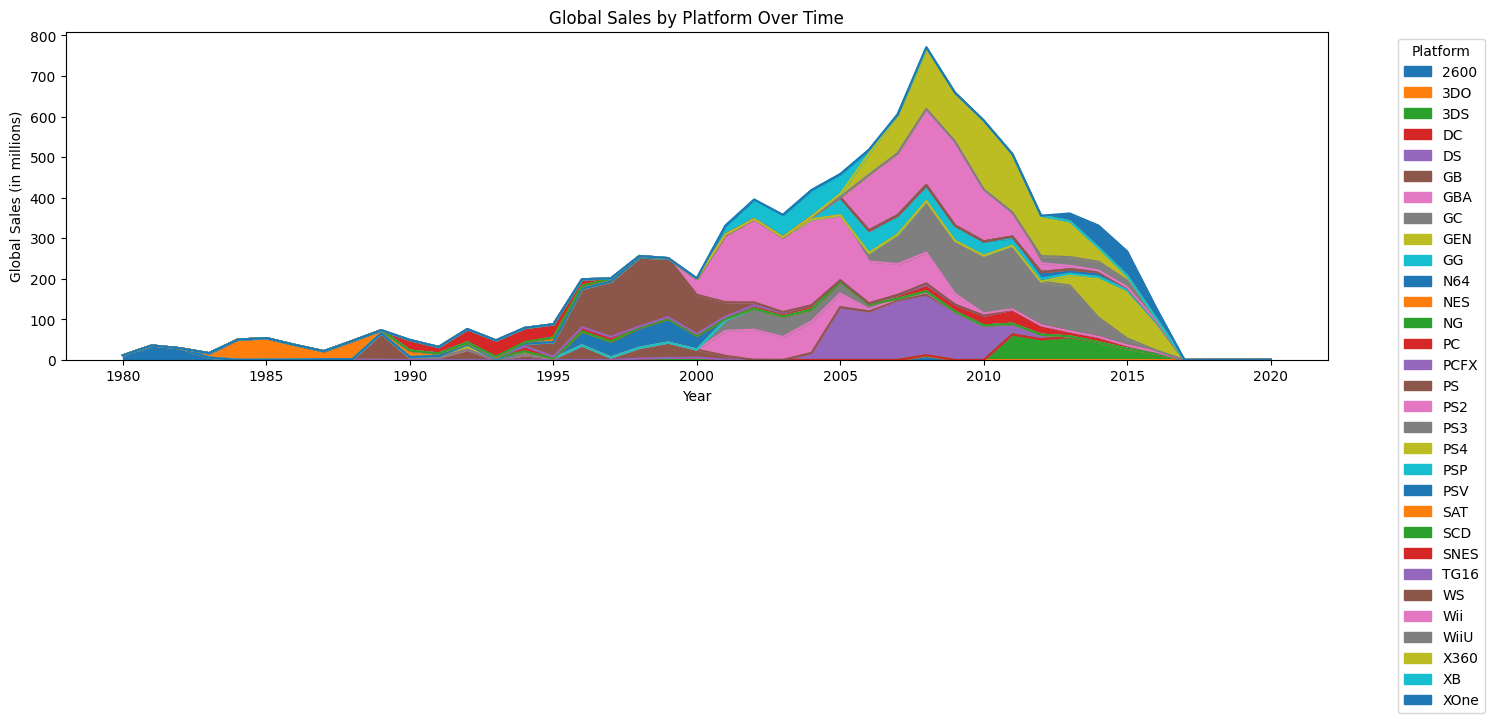

In [200]:
platform_year_sales = df.groupby(['Year_of_Release', 'Platform'])['Global_Sales'].sum().unstack()
platform_year_sales.plot(kind='area', stacked=True,figsize=(15,6))
plt.title('Global Sales by Platform Over Time')
plt.xlabel('Year')
plt.ylabel('Global Sales (in millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

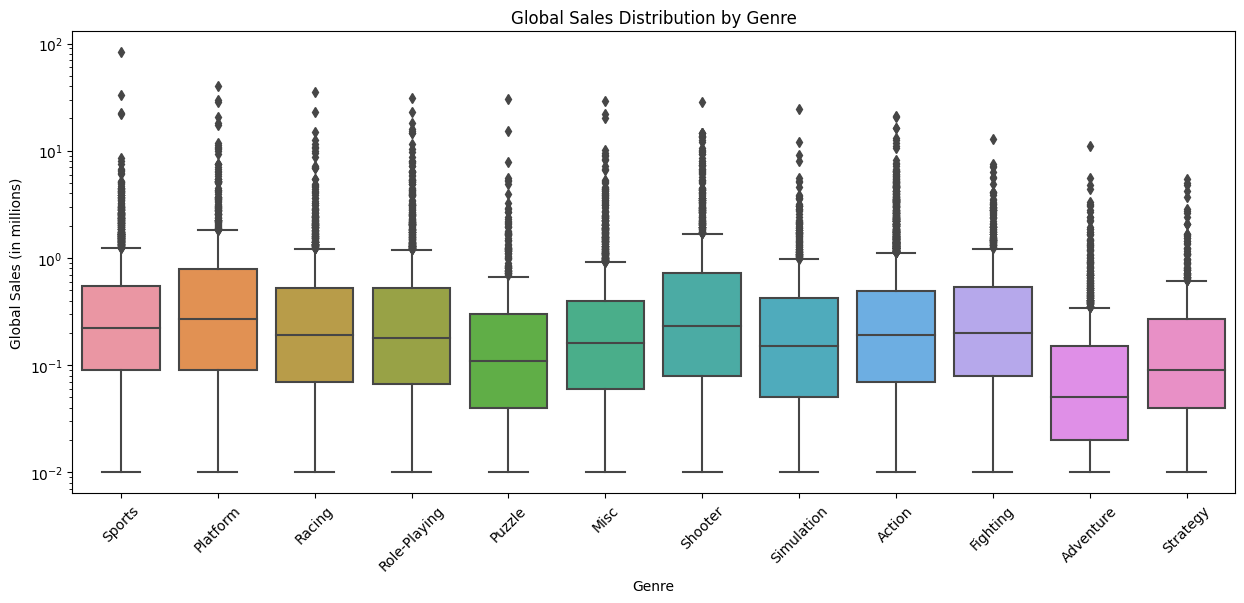

In [201]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Genre', y='Global_Sales', data=df)
plt.title('Global Sales Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales (in millions)')
plt.yscale('log')  # Log scale for better visibility
plt.xticks(rotation=45)
plt.show()

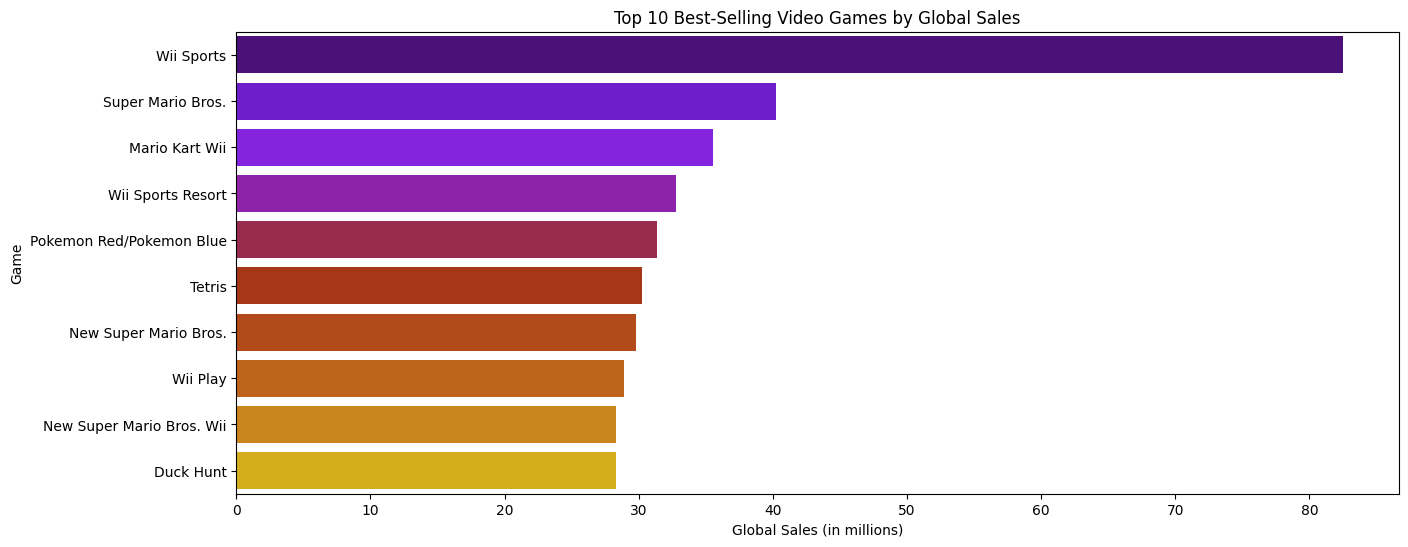

In [202]:
top_games = df.nlargest(10, 'Global_Sales')[['Name', 'Global_Sales']]
plt.figure(figsize=(15, 6))
sns.barplot(x='Global_Sales', y='Name', data=top_games,palette="gnuplot")
plt.title('Top 10 Best-Selling Video Games by Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Game')
plt.show()

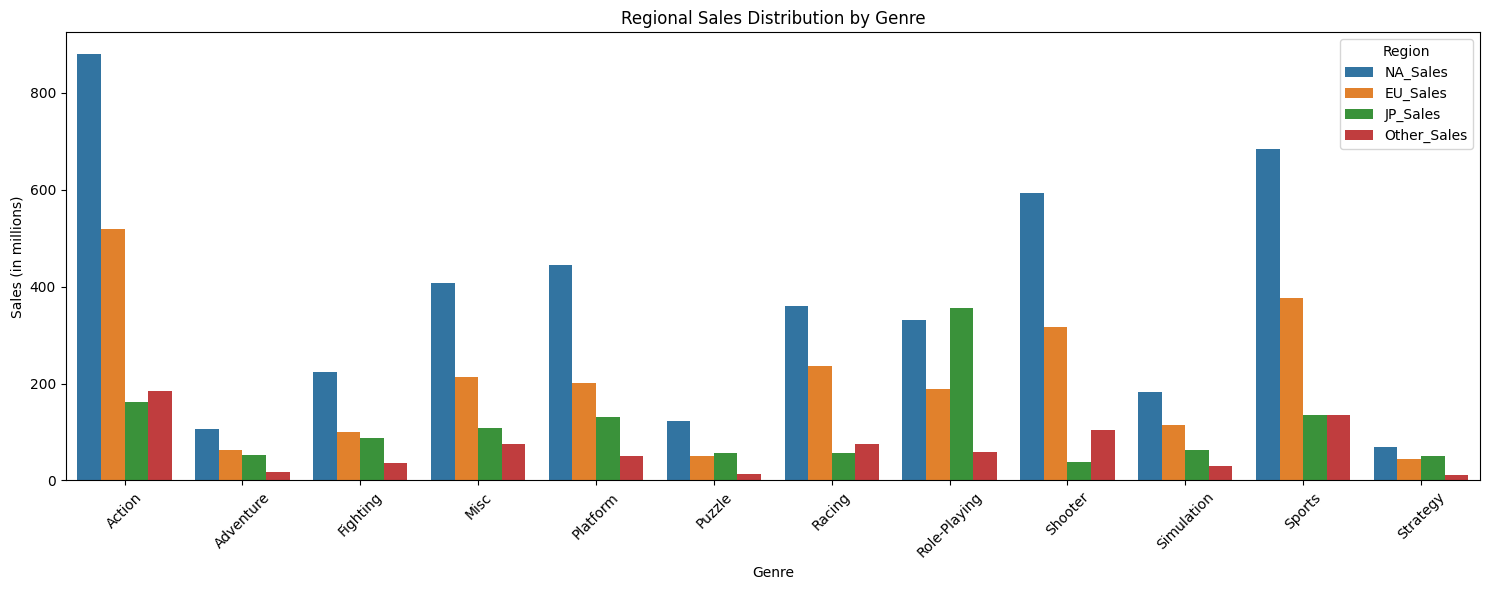

In [203]:

region_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().reset_index()

# Melt for seaborn
region_sales_melted = region_sales.melt(id_vars='Genre', 
                                        value_vars=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
                                        var_name='Region', 
                                        value_name='Sales')

# Plot
plt.figure(figsize=(15, 6))
sns.barplot(
    data=region_sales_melted,
    x='Genre',
    y='Sales',
    hue='Region',
    estimator=sum
)

plt.title('Regional Sales Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Sales (in millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

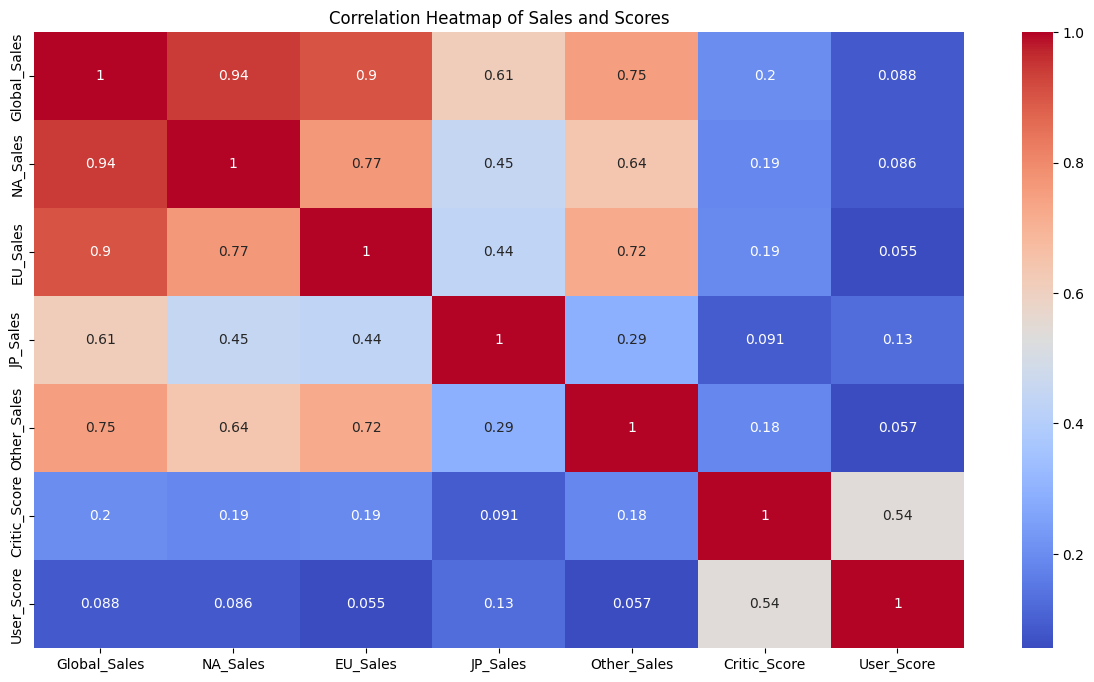

In [204]:
plt.figure(figsize=(15, 8))
sns.heatmap(df[['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score', 'User_Score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Sales and Scores')
plt.show()

In [205]:
import plotly.express as px
import plotly.graph_objects as go
fig = px.scatter(df, x='Critic_Score', y='Global_Sales', color='Genre', hover_data=['Name', 'Platform'], size='Global_Sales', log_y=True)
fig.update_layout(title='Global Sales vs. Critic Score by Genre', xaxis_title='Critic Score', yaxis_title='Global Sales (in millions, log scale)')
fig.show()

In [206]:
fig = px.scatter(df, x='Year_of_Release', y='Global_Sales', color='Genre', size='Global_Sales', hover_data=['Name', 'Platform'], facet_col='Platform', facet_col_wrap=4)
fig.update_layout(title='Global Sales by Year, Genre, and Platform', height=800)
fig.show()

In [207]:
df.drop(columns=["Name","User_Score"],axis=1,inplace=True)

In [208]:
df.head()

,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count,Developer,Rating
0,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.000000,51.0,322.000000,Nintendo,E
1,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,68.967679,4.0,162.229908,Ubisoft,E
2,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.000000,73.0,709.000000,Nintendo,E
3,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.000000,73.0,192.000000,Nintendo,E
4,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,68.967679,4.0,162.229908,Ubisoft,E


In [209]:
cols=["Platform","Genre","Publisher","Developer","Rating"]

In [210]:

from sklearn.preprocessing import OneHotEncoder

cols = ["Platform", "Genre", "Publisher", "Developer", "Rating"]

encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[cols])

encoded_cols = encoder.get_feature_names_out(cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

df_encoded = df.drop(columns=cols).join(encoded_df)

df_encoded.head()


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count,Platform_2600,...,Developer_syn Sophia,Developer_zSlide,Rating_AO,Rating_E,Rating_E10+,Rating_EC,Rating_K-A,Rating_M,Rating_RP,Rating_T
0,2006,41.36,28.96,3.77,8.45,82.53,76.000000,51.0,322.000000,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1985,29.08,3.58,6.81,0.77,40.24,68.967679,4.0,162.229908,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2008,15.68,12.76,3.79,3.29,35.52,82.000000,73.0,709.000000,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2009,15.61,10.93,3.28,2.95,32.77,80.000000,73.0,192.000000,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1996,11.27,8.89,10.22,1.00,31.37,68.967679,4.0,162.229908,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [211]:
from sklearn.ensemble import RandomForestRegressor
X = df_encoded.drop(columns=['Global_Sales'])
y = df_encoded['Global_Sales']

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

feat_importances = pd.DataFrame({'feature': X.columns,'importance': rf.feature_importances_})

top5 = feat_importances.sort_values(by='importance', ascending=False).head(5)
print("Top 5 features by importance:")
print(top5)

Top 5 features by importance:
         feature  importance
1       NA_Sales    0.831304
2       EU_Sales    0.109456
3       JP_Sales    0.026389
4    Other_Sales    0.025242
49  Genre_Sports    0.001526


In [212]:
top_features = top5['feature'].tolist()
df=df_encoded[top_features + ['Global_Sales']]
df.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Genre_Sports,Global_Sales
0,41.36,28.96,3.77,8.45,1.0,82.53
1,29.08,3.58,6.81,0.77,0.0,40.24
2,15.68,12.76,3.79,3.29,0.0,35.52
3,15.61,10.93,3.28,2.95,1.0,32.77
4,11.27,8.89,10.22,1.00,0.0,31.37


In [213]:
X = df.drop(columns=['Global_Sales'])
y = df['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [214]:
from catboost import CatBoostRegressor
model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

0:	learn: 1.2995215	test: 1.9314040	best: 1.9314040 (0)	total: 3.38ms	remaining: 3.38s
100:	learn: 0.0730790	test: 0.9341844	best: 0.9341844 (100)	total: 215ms	remaining: 1.91s
200:	learn: 0.0359848	test: 0.9182117	best: 0.9181889 (199)	total: 428ms	remaining: 1.7s
300:	learn: 0.0248049	test: 0.9158335	best: 0.9158000 (299)	total: 651ms	remaining: 1.51s
400:	learn: 0.0193714	test: 0.9145466	best: 0.9145332 (397)	total: 872ms	remaining: 1.3s
500:	learn: 0.0157760	test: 0.9142708	best: 0.9142431 (496)	total: 1.1s	remaining: 1.09s
600:	learn: 0.0136420	test: 0.9140020	best: 0.9140020 (600)	total: 1.32s	remaining: 879ms
700:	learn: 0.0118402	test: 0.9138907	best: 0.9138907 (700)	total: 1.54s	remaining: 659ms
800:	learn: 0.0105523	test: 0.9137031	best: 0.9136944 (796)	total: 1.76s	remaining: 438ms
900:	learn: 0.0096195	test: 0.9135952	best: 0.9135879 (884)	total: 1.98s	remaining: 218ms
999:	learn: 0.0088826	test: 0.9134614	best: 0.9134560 (997)	total: 2.19s	remaining: 0us

bestTest = 0.9134

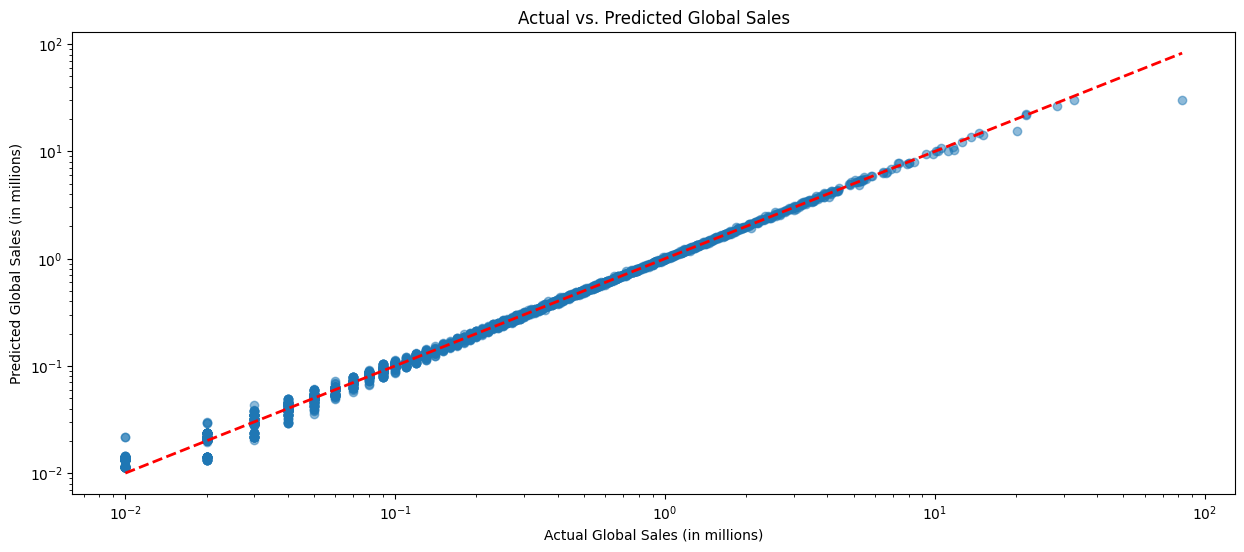

In [215]:
# Create results DataFrame
y_pred=model.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
# Merge with test features
test_df = X_test.join(results)
# Add absolute error for analysis
test_df['Absolute_Error'] = abs(test_df['Actual'] - test_df['Predicted'])

plt.figure(figsize=(15, 6))
plt.scatter(results['Actual'], results['Predicted'], alpha=0.5)
plt.plot([results['Actual'].min(), results['Actual'].max()], [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2)
plt.xlabel('Actual Global Sales (in millions)')
plt.ylabel('Predicted Global Sales (in millions)')
plt.title('Actual vs. Predicted Global Sales')
plt.xscale('log')
plt.yscale('log')
plt.show()

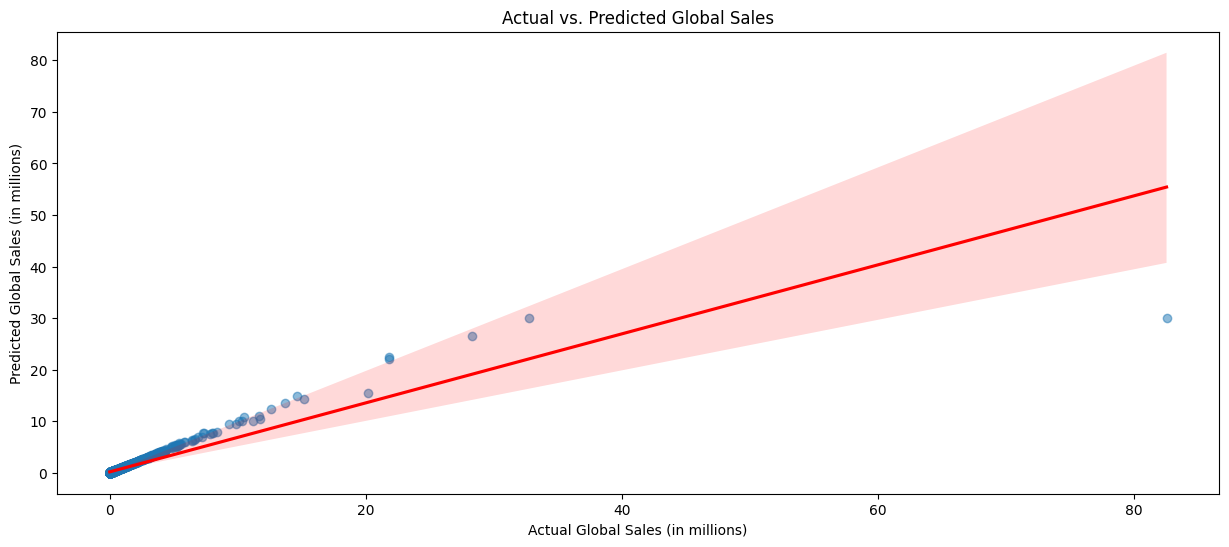

In [216]:
plt.figure(figsize=(15, 6))
sns.regplot(x='Actual', y='Predicted', data=results, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Actual Global Sales (in millions)')
plt.ylabel('Predicted Global Sales (in millions)')
plt.title('Actual vs. Predicted Global Sales')
plt.show()

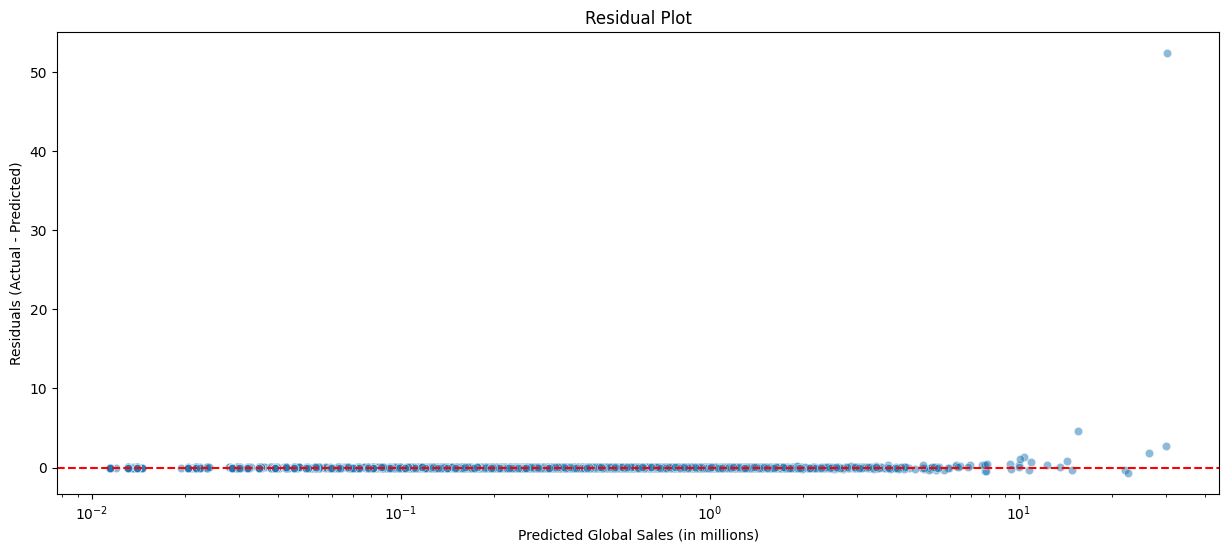

In [217]:
results['Residuals'] = results['Actual'] - results['Predicted']
plt.figure(figsize=(15, 6))
sns.scatterplot(x=results['Predicted'], y=results['Residuals'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Global Sales (in millions)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.xscale('log')
plt.show()

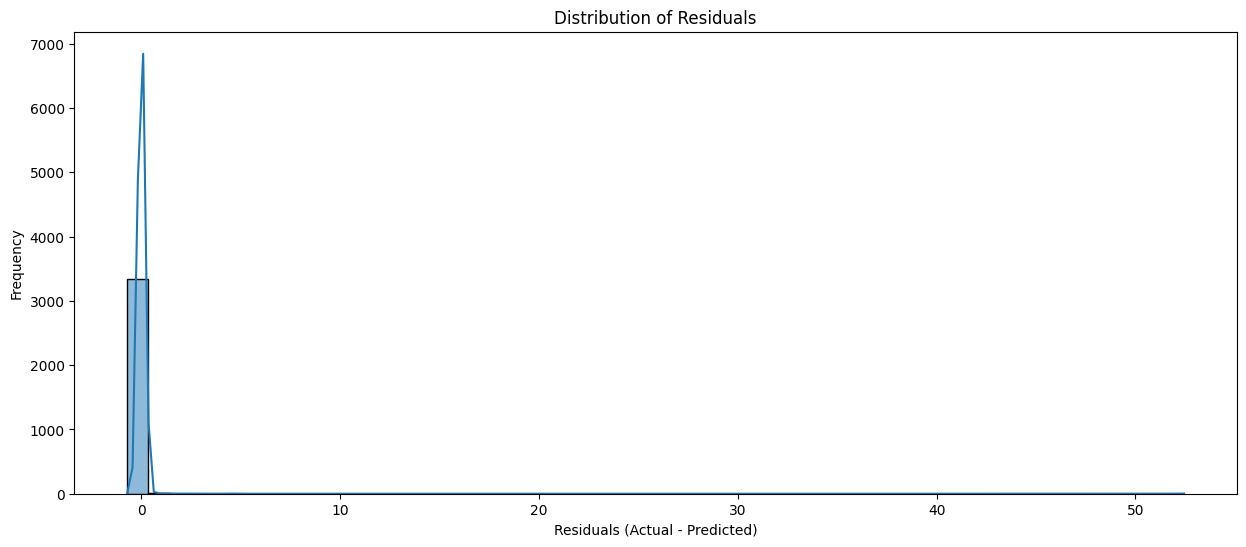

In [218]:
plt.figure(figsize=(15, 6))
sns.histplot(results['Residuals'], bins=50, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

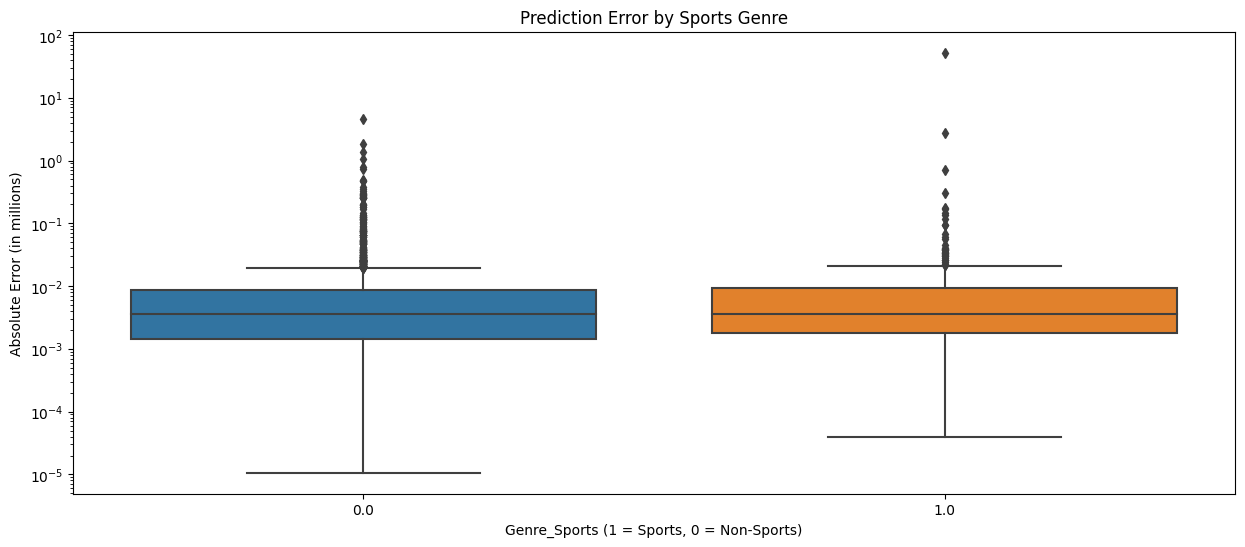

In [219]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Genre_Sports', y='Absolute_Error', data=test_df)
plt.title('Prediction Error by Sports Genre')
plt.xlabel('Genre_Sports (1 = Sports, 0 = Non-Sports)')
plt.ylabel('Absolute Error (in millions)')
plt.yscale('log')
plt.show()

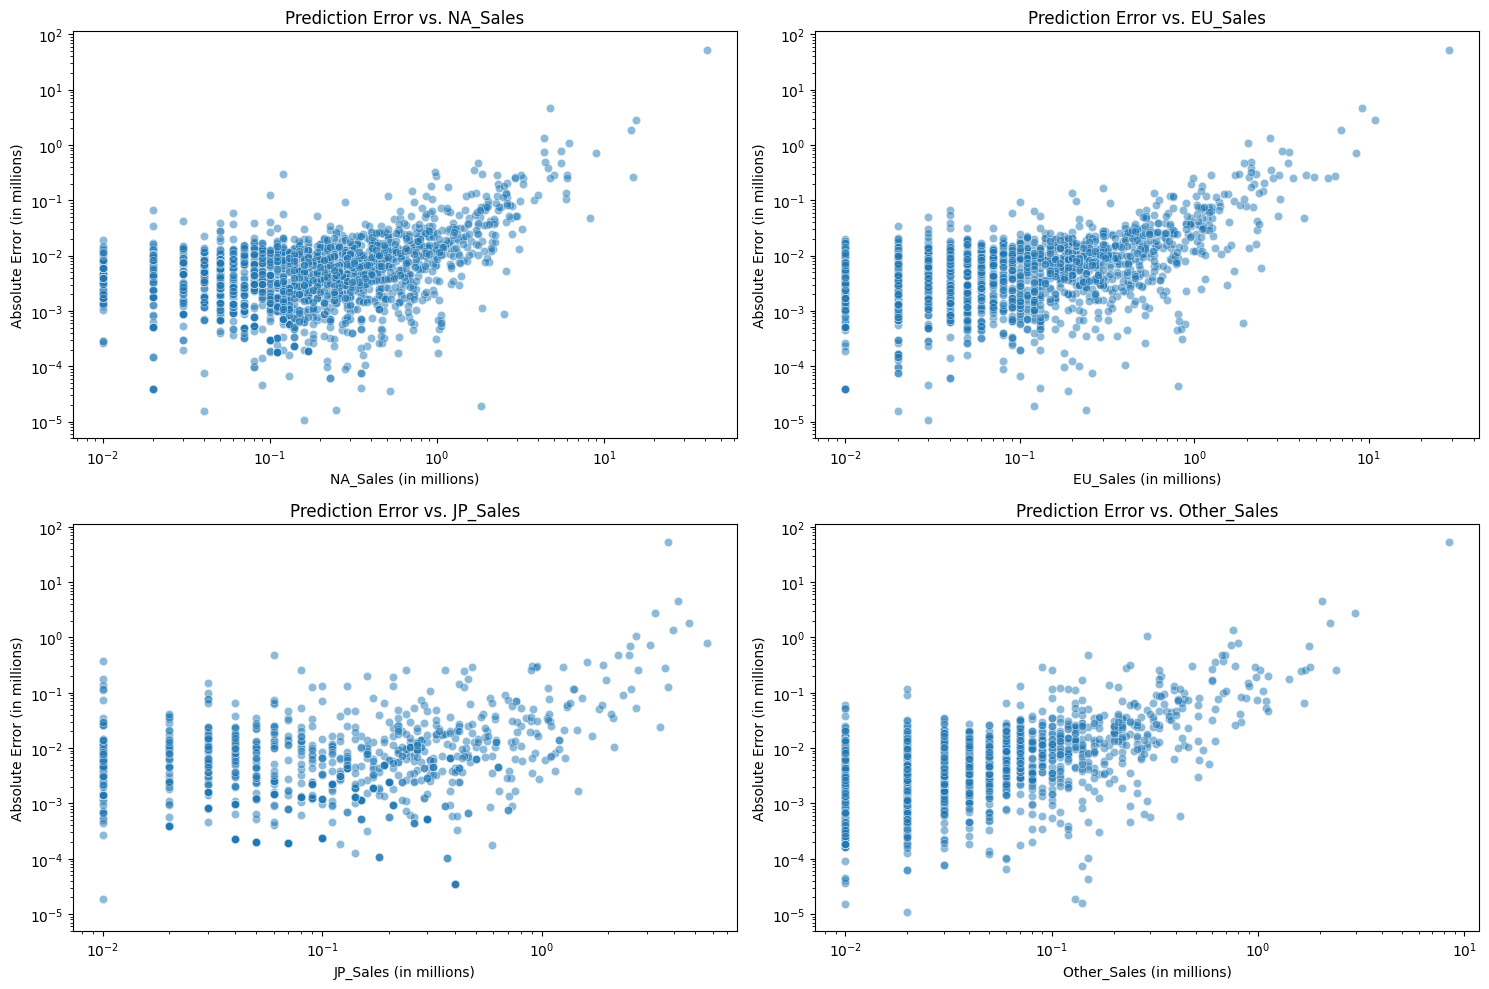

In [220]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
for i, region in enumerate(regions):
    ax = axes[i//2, i%2]
    sns.scatterplot(x=test_df[region], y=test_df['Absolute_Error'], alpha=0.5, ax=ax)
    ax.set_xlabel(f'{region} (in millions)')
    ax.set_ylabel('Absolute Error (in millions)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Prediction Error vs. {region}')
plt.tight_layout()
plt.show()

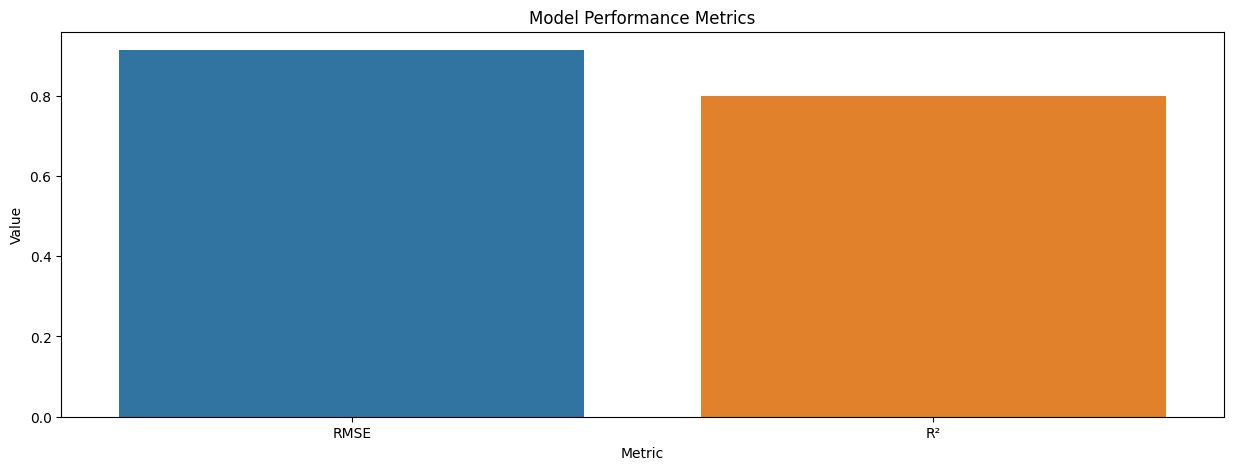

RMSE: 0.91, R²: 0.80


In [221]:
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
metrics = pd.DataFrame({'Metric': ['RMSE', 'R²'], 'Value': [rmse, r2]})
plt.figure(figsize=(15, 5))
sns.barplot(x='Metric', y='Value', data=metrics)
plt.title('Model Performance Metrics')
plt.ylabel('Value')
plt.show()
print(f"RMSE: {rmse:.2f}, R²: {r2:.2f}")

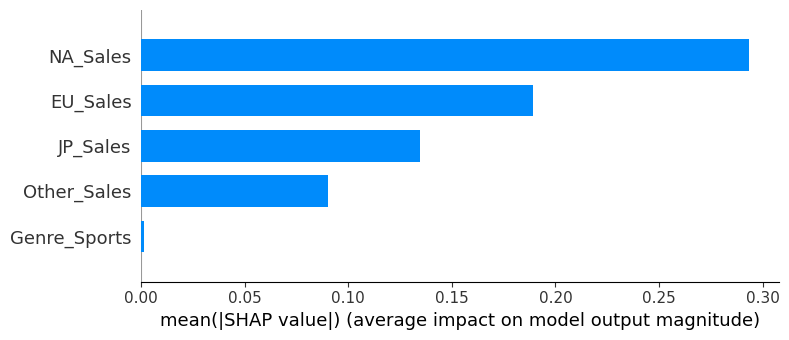

In [222]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [223]:
fig = px.scatter(results, x='Actual', y='Predicted', hover_data=[results.index], log_x=True, log_y=True)
fig.add_trace(go.Scatter(x=[results['Actual'].min(), results['Actual'].max()], 
                         y=[results['Actual'].min(), results['Actual'].max()], 
                         mode='lines', line=dict(color='red', dash='dash'), name='Perfect Fit'))
fig.update_layout(title='Actual vs. Predicted Global Sales (Interactive)', 
                  xaxis_title='Actual Global Sales (log scale)', 
                  yaxis_title='Predicted Global Sales (log scale)')
fig.show()

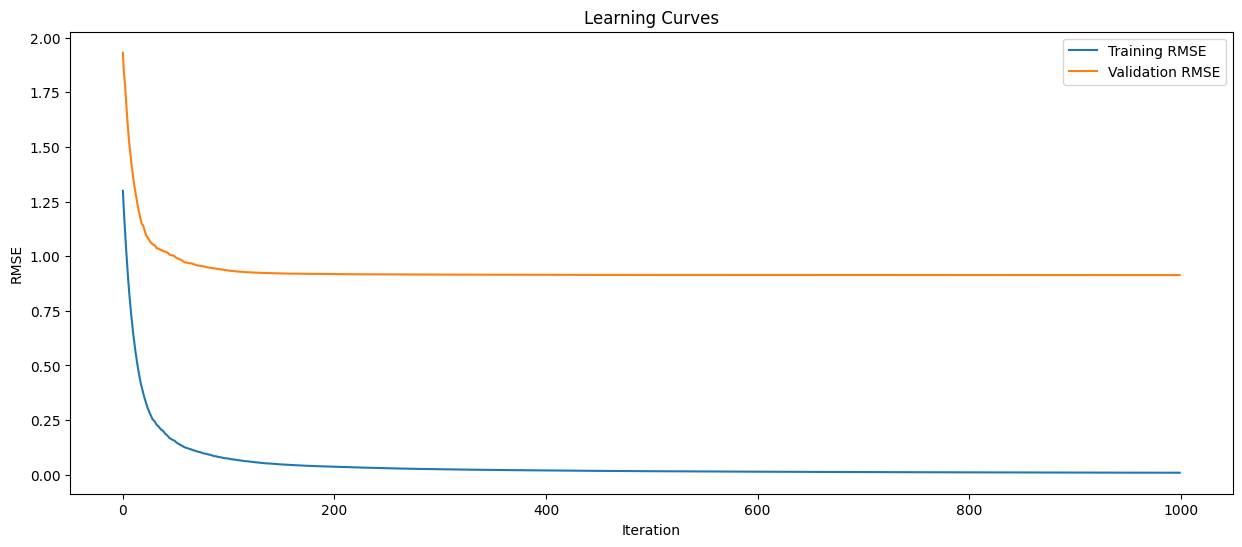

In [224]:
evals_result = model.get_evals_result()
plt.figure(figsize=(15, 6))
plt.plot(evals_result['learn']['RMSE'], label='Training RMSE')
plt.plot(evals_result['validation']['RMSE'], label='Validation RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Learning Curves')
plt.legend()
plt.show()

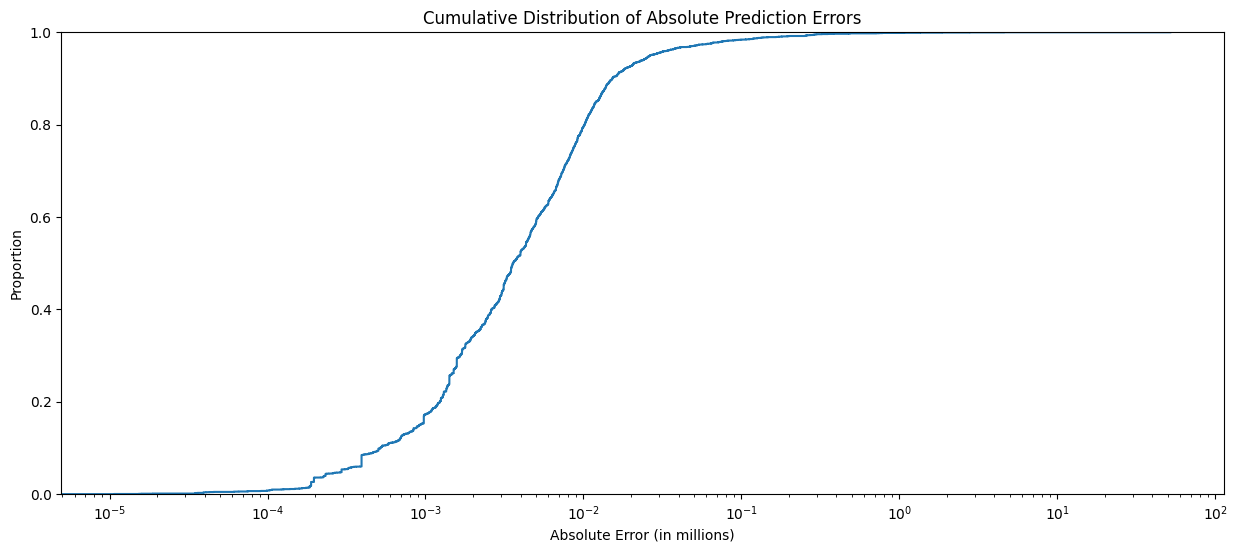

In [225]:
plt.figure(figsize=(15, 6))
sns.ecdfplot(data=test_df, x='Absolute_Error')
plt.title('Cumulative Distribution of Absolute Prediction Errors')
plt.xlabel('Absolute Error (in millions)')
plt.ylabel('Proportion')
plt.xscale('log')
plt.show()